# **TFG INGENIERÍA INFORMÁTICA**
**Autor:** Gabriela Fernández-Flores Gila\
**Universidad:** CUNEF\
**Objetivo:** Desarrollo de un modelo de Machine Learning para la predicción de precios
de activos inmobiliarios mediante regresión avanzada y redes neuronales.\
Se comparan dos variables objetivo: el z-score global del log(precio) y la desviación
respecto al precio medio del barrio. La validación se realiza con K-Fold (k=10).

## Instrucciones de ejecución

Este notebook está desarrollado en Google Colab.

**Antes de ejecutar**, sube el dataset al entorno de Colab:
1. Descarga el dataset desde Kaggle:
   [Madrid real estate market](https://www.kaggle.com/datasets/mirbektoktogaraev/madrid-real-estate-market)
2. En el panel izquierdo de Colab, haz clic en el icono de carpeta 📁
3. Arrastra el archivo `houses_Madrid.csv` al panel de archivos
4. Ejecuta todas las celdas: **Entorno de ejecución → Ejecutar todo**


# **0. Librerías**
Importamos todas las librerías necesarias para el proyecto completo.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# **1. Carga del dataset**
Cargamos el dataset `houses_Madrid.csv` que contiene 21.742 inmuebles
en venta en Madrid con 58 variables sobre características físicas, ubicación y precio.

In [2]:
df = pd.read_csv('houses_Madrid.csv')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Filas: 21742 | Columnas: 58


,Unnamed: 0,id,title,subtitle,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,...,energy_certificate,has_parking,has_private_parking,has_public_parking,is_parking_included_in_price,parking_price,is_orientation_north,is_orientation_west,is_orientation_south,is_orientation_east
0,0,21742,"Piso en venta en calle de Godella, 64","San Cristóbal, Madrid",64.0,60.0,2,1.0,NaN,NaN,...,D,False,NaN,NaN,NaN,NaN,False,True,False,False
1,1,21741,Piso en venta en calle de la del Manojo de Rosas,"Los Ángeles, Madrid",70.0,NaN,3,1.0,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,21740,"Piso en venta en calle del Talco, 68","San Andrés, Madrid",94.0,54.0,2,2.0,NaN,NaN,...,no indicado,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,21739,Piso en venta en calle Pedro Jiménez,"San Andrés, Madrid",64.0,NaN,2,1.0,NaN,NaN,...,en trámite,False,NaN,NaN,NaN,NaN,False,False,True,False
4,4,21738,Piso en venta en carretera de Villaverde a Val...,"Los Rosales, Madrid",108.0,90.0,2,2.0,NaN,NaN,...,en trámite,True,NaN,NaN,True,0.0,True,True,True,True


## **1.1)** Dimensiones y tipos de variables
Distinguimos entre variables numéricas y categóricas para planificar el preprocesado.

In [3]:
categoricas_inic = df.select_dtypes(include=['object'])
numericas_inic   = df.select_dtypes(include=['int', 'float'])
print(f'Variables categóricas: {len(categoricas_inic.columns)}')
print(f'Variables numéricas:   {len(numericas_inic.columns)}')
print(f'Total observaciones:   {len(df)}')


Variables categóricas: 30
Variables numéricas:   23
Total observaciones:   21742


## **1.2)** Eliminación del índice redundante
El CSV incluye una columna `Unnamed: 0` que es el índice original del archivo.
No aporta información predictiva y la eliminamos.

In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f'Shape tras eliminar índice: {df.shape}')


Shape tras eliminar índice: (21742, 57)


# **2. Overview del dataset**

## **2.1)** Renombrado de variables
Renombramos las columnas más importantes para mayor claridad semántica.

In [5]:
rename_dict = {
    'sq_mt_built':    'area_m2',
    'n_rooms':        'rooms',
    'n_bathrooms':    'bathrooms',
    'buy_price':      'price',
    'buy_price_by_area': 'price_m2',
    'house_type_id':  'property_type',
    'neighborhood_id':'location_details',
    'built_year':     'year_built',
    'is_floor_under': 'is_ground_floor'
}
df = df.rename(columns=rename_dict)
print('Columnas tras renombrado:')
print(df.columns.tolist())


Columnas tras renombrado:
['id', 'title', 'subtitle', 'area_m2', 'sq_mt_useful', 'rooms', 'bathrooms', 'n_floors', 'sq_mt_allotment', 'latitude', 'longitude', 'raw_address', 'is_exact_address_hidden', 'street_name', 'street_number', 'portal', 'floor', 'is_ground_floor', 'door', 'location_details', 'operation', 'rent_price', 'rent_price_by_area', 'is_rent_price_known', 'price', 'price_m2', 'is_buy_price_known', 'property_type', 'is_renewal_needed', 'is_new_development', 'year_built', 'has_central_heating', 'has_individual_heating', 'are_pets_allowed', 'has_ac', 'has_fitted_wardrobes', 'has_lift', 'is_exterior', 'has_garden', 'has_pool', 'has_terrace', 'has_balcony', 'has_storage_room', 'is_furnished', 'is_kitchen_equipped', 'is_accessible', 'has_green_zones', 'energy_certificate', 'has_parking', 'has_private_parking', 'has_public_parking', 'is_parking_included_in_price', 'parking_price', 'is_orientation_north', 'is_orientation_west', 'is_orientation_south', 'is_orientation_east']


## **2.2)** Estadísticas descriptivas
Primer vistazo a la distribución de las variables numéricas.

In [6]:
df.describe().round(2)

,id,area_m2,sq_mt_useful,rooms,bathrooms,n_floors,sq_mt_allotment,latitude,longitude,portal,...,rent_price_by_area,price,price_m2,year_built,are_pets_allowed,is_furnished,is_kitchen_equipped,has_private_parking,has_public_parking,parking_price
count,21742.00,21616.00,8228.00,21742.00,21726.00,1437.00,1432.00,0.0,0.0,0.0,...,0.0,21742.00,21742.00,10000.00,0.0,0.0,0.0,0.0,0.0,7719.00
mean,10871.50,146.92,103.46,3.01,2.09,3.13,241.69,NaN,NaN,NaN,...,NaN,653735.65,4020.52,1970.05,NaN,NaN,NaN,NaN,NaN,2658.00
std,6276.52,134.18,88.26,1.51,1.41,0.91,247.48,NaN,NaN,NaN,...,NaN,782082.07,1908.42,69.39,NaN,NaN,NaN,NaN,NaN,13360.97
min,1.00,13.00,1.00,0.00,1.00,1.00,1.00,NaN,NaN,NaN,...,NaN,36000.00,447.00,1723.00,NaN,NaN,NaN,NaN,NaN,0.00
25%,5436.25,70.00,59.00,2.00,1.00,2.00,2.00,NaN,NaN,NaN,...,NaN,198000.00,2551.00,1957.00,NaN,NaN,NaN,NaN,NaN,0.00
50%,10871.50,100.00,79.00,3.00,2.00,3.00,232.00,NaN,NaN,NaN,...,NaN,375000.00,3720.00,1970.00,NaN,NaN,NaN,NaN,NaN,0.00
75%,16306.75,162.00,113.00,4.00,2.00,4.00,354.00,NaN,NaN,NaN,...,NaN,763600.00,5000.00,1994.00,NaN,NaN,NaN,NaN,NaN,0.00
max,21742.00,999.00,998.00,24.00,16.00,7.00,997.00,NaN,NaN,NaN,...,NaN,8800000.00,18889.00,8170.00,NaN,NaN,NaN,NaN,NaN,600000.00


> **Observaciones clave:** el precio medio es 653.736€ pero la mediana es 375.000€,
> lo que indica una fuerte asimetría positiva (skewness ~3.3). El área varía entre
> 20 y 13.000 m², señalando la presencia de outliers. Esto justifica la transformación
> logarítmica que aplicaremos en la Sección 5.

# **3. Preprocesado de los datos**

## **3.1)** Análisis de valores nulos
Calculamos el porcentaje de nulos por columna para decidir qué variables
eliminar y cuáles imputar.

In [7]:
nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('Porcentaje de nulos por columna:')
print(nulos_pct[nulos_pct > 0].round(2).to_string())

Porcentaje de nulos por columna:
latitude                        100.00
door                            100.00
portal                          100.00
longitude                       100.00
rent_price_by_area              100.00
is_kitchen_equipped             100.00
is_furnished                    100.00
has_public_parking              100.00
are_pets_allowed                100.00
has_private_parking             100.00
sq_mt_allotment                  93.41
n_floors                         93.39
has_garden                       92.84
has_balcony                      84.73
has_green_zones                  81.34
is_accessible                    81.26
has_pool                         76.22
street_number                    71.02
has_storage_room                 64.59
is_parking_included_in_price     64.50
parking_price                    64.50
sq_mt_useful                     62.16
has_terrace                      56.08
year_built                       54.01
has_ac                         

Observamos que las columnas `has_private_parking`, `has_public_parking`,
`is_kitchen_equipped`, `is_furnished`, `are_pets_allowed`, `rent_price_by_area`,
`door`, `portal`, `latitude` y `longitude` tienen un **100% de valores nulos**
y por tanto las eliminamos directamente.


In [8]:
cols_100_null = ['latitude', 'longitude', 'portal', 'door', 'rent_price_by_area',
                 'are_pets_allowed', 'is_furnished', 'is_kitchen_equipped',
                 'has_private_parking', 'has_public_parking']
df.drop(columns=cols_100_null, inplace=True)
print(f'Shape tras eliminar columnas 100% nulas: {df.shape}')

Shape tras eliminar columnas 100% nulas: (21742, 47)


## **3.2)** Eliminación de variables no relevantes para el modelo
Eliminamos variables con más del 80% de nulos, identificadores de texto
sin valor predictivo, y variables de alquiler (nuestro objetivo es la compra).

In [9]:
high_null  = ['sq_mt_allotment', 'n_floors', 'has_garden', 'has_balcony',
              'has_green_zones', 'is_accessible', 'has_pool', 'street_number']
non_useful = ['id', 'title', 'subtitle', 'raw_address', 'street_name',
              'operation',              # valor único: 'sale'
              'rent_price', 'is_rent_price_known',
              'is_buy_price_known',      # todos True
              'is_exact_address_hidden',
              'parking_price', 'is_parking_included_in_price']

to_drop = [c for c in high_null + non_useful if c in df.columns]
df.drop(columns=to_drop, inplace=True)
print(f'Columnas eliminadas: {len(to_drop)}')
print(f'Columnas restantes:  {df.shape[1]}')
print(df.columns.tolist())

Columnas eliminadas: 20
Columnas restantes:  27
['area_m2', 'sq_mt_useful', 'rooms', 'bathrooms', 'floor', 'is_ground_floor', 'location_details', 'price', 'price_m2', 'property_type', 'is_renewal_needed', 'is_new_development', 'year_built', 'has_central_heating', 'has_individual_heating', 'has_ac', 'has_fitted_wardrobes', 'has_lift', 'is_exterior', 'has_terrace', 'has_storage_room', 'energy_certificate', 'has_parking', 'is_orientation_north', 'is_orientation_west', 'is_orientation_south', 'is_orientation_east']


## **3.3)** Extracción de información de variables complejas
La columna `location_details` contiene barrio, precio medio/m² y distrito
en formato texto. La parseamos con expresiones regulares para extraer
tres variables independientes. Guardamos el mapping barrio→log_media
antes del OHE para poder calcular el Target B más adelante sin recargar el CSV.

In [10]:
df['neighborhood'] = df['location_details'].str.extract(r'Neighborhood \d+: (.+?) \(')
df['neighborhood_avg_price_m2'] = (
    df['location_details'].str.extract(r'\(([\d.]+) €/m2\)').astype(float)
)
df['district'] = df['location_details'].str.extract(r'District \d+: (.+)$')
df['property_type'] = df['property_type'].str.extract(r': (.+)')
df.drop(columns=['location_details'], inplace=True)

# Guardamos el mapping barrio → media del log(precio) para el Target B
# Lo calculamos ahora, antes del OHE, mientras 'neighborhood' y 'price' siguen disponibles
df['log_price_temp'] = np.log(df['price'])
BARRIO_LOG_MEAN = df.groupby('neighborhood')['log_price_temp'].mean()
df['neighborhood_log_mean'] = df['neighborhood'].map(BARRIO_LOG_MEAN)
df.drop(columns=['log_price_temp'], inplace=True)

print(df[['neighborhood', 'neighborhood_avg_price_m2', 'district', 'property_type']].head())
print(f'\nMapping barrio guardado: {len(BARRIO_LOG_MEAN)} barrios')


    neighborhood  neighborhood_avg_price_m2    district property_type
0  San Cristóbal                    1308.89  Villaverde         Pisos
1    Los Ángeles                    1796.68  Villaverde         Pisos
2     San Andrés                    1617.18  Villaverde         Pisos
3     San Andrés                    1617.18  Villaverde         Pisos
4    Los Rosales                    1827.79  Villaverde         Pisos

Mapping barrio guardado: 126 barrios


## **3.4)** Codificación ordinal de la variable `floor`
El piso tiene una relación ordinal con el precio (los pisos altos suelen ser
más caros). Lo convertimos a entero. Los valores no reconocidos se tratan
con un fallback numérico.

In [11]:
floor_map = {
    'Sótano': -2, 'Sótano interior': -2, 'Sótano exterior': -2,
    'Semi-sótano': -1, 'Semi-sótano interior': -1, 'Semi-sótano exterior': -1,
    'Bajo': 0, 'Entreplanta': 0, 'Entreplanta interior': 0, 'Entreplanta exterior': 0,
    **{str(i): i for i in range(1, 21)}
}

def parse_floor(val):
    if pd.isna(val): return np.nan
    if val in floor_map: return floor_map[val]
    match = re.search(r'\d+', str(val))
    return int(match.group()) if match else np.nan

df['floor_num'] = df['floor'].apply(parse_floor)
df.drop(columns=['floor'], inplace=True)
print(f'NaN en floor_num: {df["floor_num"].isna().sum()} (solo NaN originales del dataset)')
print(df['floor_num'].value_counts(dropna=False).head(8))


NaN en floor_num: 2607 (solo NaN originales del dataset)
floor_num
1.0    4440
2.0    3546
3.0    3001
NaN    2607
0.0    2415
4.0    2323
5.0    1310
6.0     913
Name: count, dtype: int64


## **3.5)** Imputación de valores nulos
- **Variables binarias**: NaN indica que la característica no se menciona en el anuncio,
  lo interpretamos como ausencia → imputamos con `False`.
- **Variables numéricas**: imputamos con la mediana, robusta frente a outliers.
- **Variables categóricas**: imputamos con la moda (valor más frecuente).

In [12]:
binary_cols = ['is_ground_floor', 'is_new_development', 'has_central_heating',
               'has_individual_heating', 'has_ac', 'has_fitted_wardrobes',
               'has_lift', 'is_exterior', 'has_terrace', 'has_storage_room',
               'is_renewal_needed', 'has_parking', 'is_orientation_north',
               'is_orientation_west', 'is_orientation_south', 'is_orientation_east']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].where(df[col].notna(), other=False).astype(bool).astype(int)

num_cols = ['area_m2', 'sq_mt_useful', 'bathrooms', 'year_built',
            'floor_num', 'neighborhood_avg_price_m2']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if 'property_type' in df.columns:
    moda = df['property_type'].mode()[0]
    df['property_type'] = df['property_type'].fillna(moda)
    print(f'property_type: nulos imputados con moda → "{moda}"')

print(f'Nulos restantes: {df.isnull().sum().sum()}')  # debe ser 0


property_type: nulos imputados con moda → "Pisos"
Nulos restantes: 0


## **3.6)** Codificación de variables categóricas
*Esta sección se ejecuta después del EDA para poder analizar las variables*
*en su escala original antes de transformarlas.*

- `energy_certificate`: codificación ordinal (A=7 mejor eficiencia, G=1 peor)
- `property_type` y `district`: One-Hot Encoding
- `neighborhood`: ya capturado en `neighborhood_avg_price_m2` → eliminamos el texto

In [13]:
energy_order = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1,
                'en trámite': 0, 'no indicado': 0, 'inmueble exento': 0}
df['energy_certificate'] = df['energy_certificate'].map(energy_order).fillna(0).astype(int)

ohe_cols = [c for c in ['property_type', 'district'] if c in df.columns]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

df.drop(columns=['neighborhood'], inplace=True)

print(f'Shape final preprocesado: {df.shape}')
print(f'Tipos no numéricos: {df.select_dtypes(include=["object"]).columns.tolist()}')
df.head(3)


Shape final preprocesado: (21742, 49)
Tipos no numéricos: []


,area_m2,sq_mt_useful,rooms,bathrooms,is_ground_floor,price,price_m2,is_renewal_needed,is_new_development,year_built,...,district_Moncloa,district_Moratalaz,district_Puente de Vallecas,district_Retiro,district_Salamanca,district_Tetuán,district_Usera,district_Vicálvaro,district_Villa de Vallecas,district_Villaverde
0,64.0,60.0,2,1.0,0,85000,1328,0,0,1960.0,...,False,False,False,False,False,False,False,False,False,True
1,70.0,79.0,3,1.0,0,129900,1856,1,0,1970.0,...,False,False,False,False,False,False,False,False,False,True
2,94.0,54.0,2,2.0,0,144247,1535,0,0,1970.0,...,False,False,False,False,False,False,False,False,False,True


# **4. Análisis Exploratorio de Datos (EDA)**
Realizamos el EDA sobre el dataset limpio e imputado, **antes** de aplicar
el One-Hot Encoding, para analizar las variables en su escala original.

## **4.1)** Distribución del precio — detección de asimetría
Analizamos el sesgo para justificar la transformación logarítmica que
aplicaremos en la Sección 5.

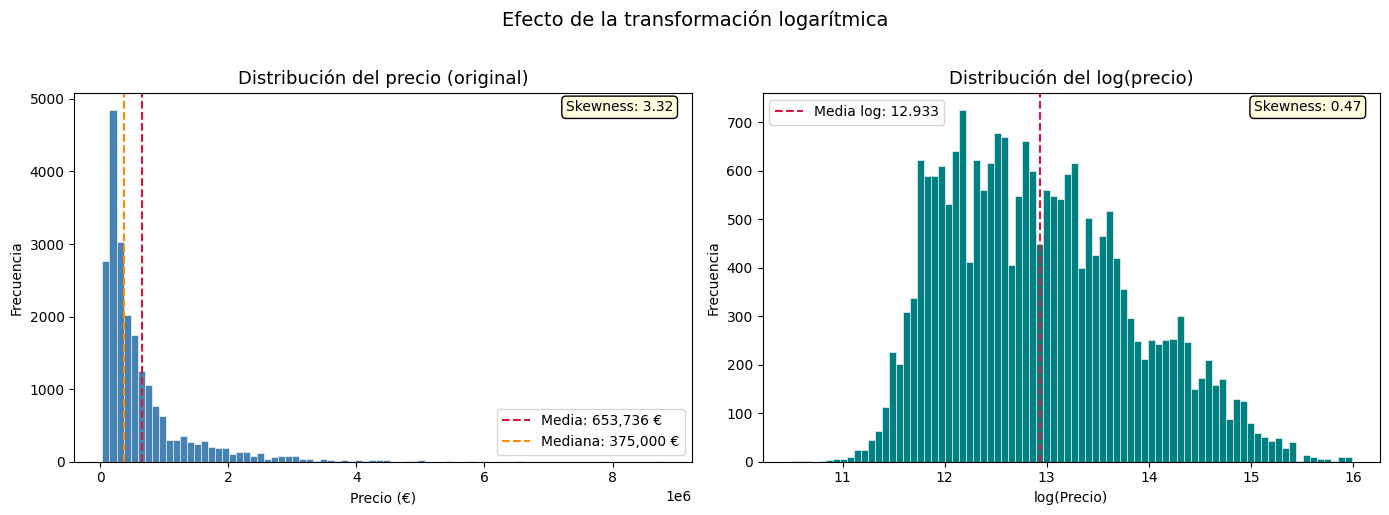

Skewness precio original: 3.324
Skewness log(precio):     0.472


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['price'].mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f"Media: {df['price'].mean():,.0f} €")
axes[0].axvline(df['price'].median(), color='darkorange', linestyle='--', linewidth=1.5,
                label=f"Mediana: {df['price'].median():,.0f} €")
axes[0].set_title('Distribución del precio (original)', fontsize=13)
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].annotate(f'Skewness: {df["price"].skew():.2f}', xy=(0.97, 0.95),
                 xycoords='axes fraction', ha='right', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

log_price = np.log(df['price'])
axes[1].hist(log_price, bins=80, color='teal', edgecolor='white', linewidth=0.4)
axes[1].axvline(log_price.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Media log: {log_price.mean():.3f}')
axes[1].set_title('Distribución del log(precio)', fontsize=13)
axes[1].set_xlabel('log(Precio)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].annotate(f'Skewness: {log_price.skew():.2f}', xy=(0.97, 0.95),
                 xycoords='axes fraction', ha='right', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

plt.suptitle('Efecto de la transformación logarítmica', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribucion_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness precio original: {df["price"].skew():.3f}')
print(f'Skewness log(precio):     {log_price.skew():.3f}')

> **Interpretación:** La distribución original presenta una asimetría positiva
> (skewness ~3.32) — la mayoría de inmuebles tienen precios bajos pero hay una
> cola larga de inmuebles de lujo. La transformación logarítmica reduce el skewness
> a ~0.47, obteniendo una distribución casi simétrica óptima para los modelos de ML.

## **4.2)** Detección de outliers con el criterio IQR

Límite superior IQR: 1,612,000 €
Outliers detectados: 1957 (9.0%)


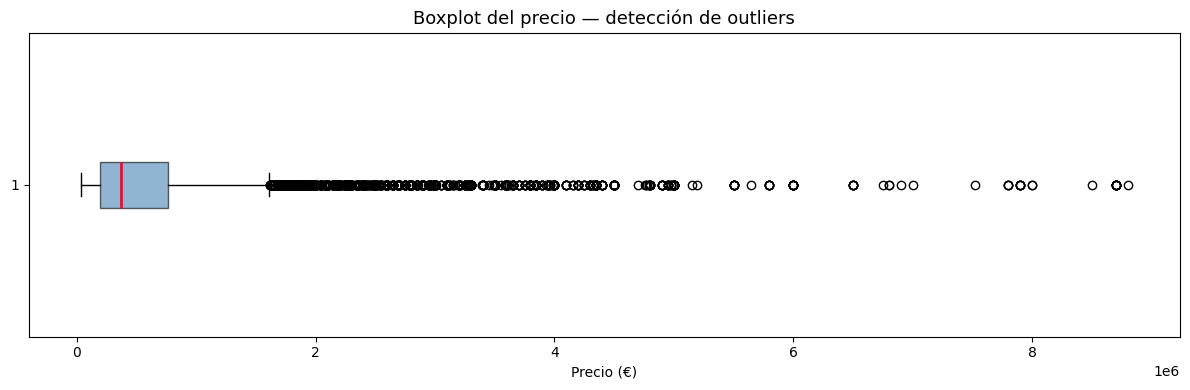

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df['price'] > upper]
print(f'Límite superior IQR: {upper:,.0f} €')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(df['price'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_xlabel('Precio (€)')
ax.set_title('Boxplot del precio — detección de outliers', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_precio.png', dpi=150, bbox_inches='tight')
plt.show()


> **Interpretación:** El 9% de los inmuebles supera el límite IQR (1.612.000€).
> No los eliminamos porque al aplicar log(precio) su efecto se reduce considerablemente,
> y los modelos basados en árboles (Random Forest, XGBoost) son robustos
> frente a outliers en la variable objetivo.


## **4.3)** Precio medio por tipo de inmueble

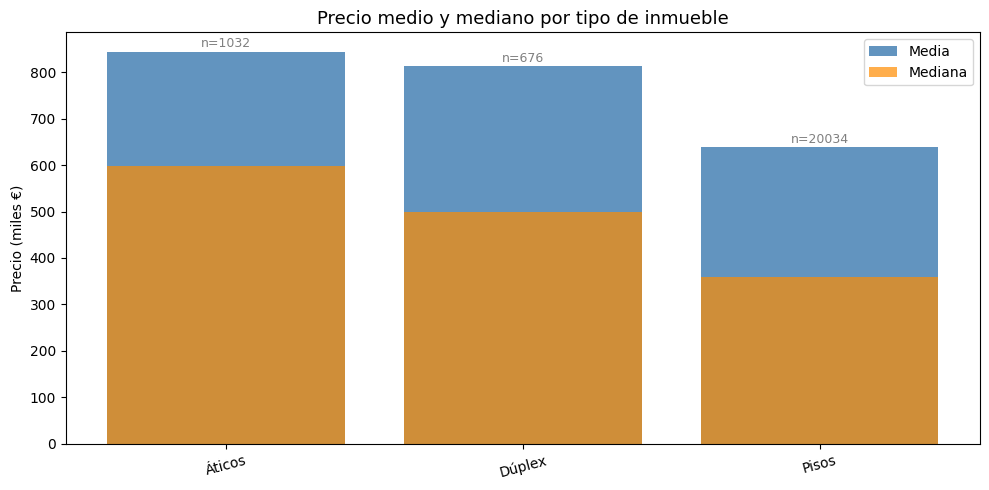

                mean    median  count
prop_label                           
Áticos      843784.0  597000.0   1032
Dúplex      813139.0  499000.0    676
Pisos       638567.0  360000.0  20034


In [16]:
# Reconstruimos la etiqueta del tipo de inmueble desde las columnas OHE
type_cols = [c for c in df.columns if c.startswith('property_type_')]
if type_cols:
    df['prop_label'] = df[type_cols].idxmax(axis=1).str.replace('property_type_', '')
    df.loc[~df[type_cols].any(axis=1), 'prop_label'] = 'Pisos'  # categoría base (drop_first)
else:
    df['prop_label'] = 'Pisos'

tipo_stats = (df.groupby('prop_label')['price']
              .agg(['mean', 'median', 'count'])
              .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(tipo_stats))
ax.bar(x, tipo_stats['mean'] / 1000, color='steelblue', label='Media', alpha=0.85)
ax.bar(x, tipo_stats['median'] / 1000, color='darkorange', label='Mediana', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(tipo_stats.index, rotation=15)
ax.set_ylabel('Precio (miles €)')
ax.set_title('Precio medio y mediano por tipo de inmueble', fontsize=13)
ax.legend()
for i, (_, row) in enumerate(tipo_stats.iterrows()):
    ax.text(i, row['mean']/1000 + 10, f"n={int(row['count'])}",
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('precio_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()
print(tipo_stats.round(0))
df.drop(columns=['prop_label'], inplace=True)  # limpiamos la columna auxiliar


> **Interpretación:** Los áticos (843k€ media) y dúplex (813k€) son significativamente
> más caros que los pisos estándar (638k€). Los pisos son el tipo más frecuente,
> con aproximadamente el 83% del dataset.

## **4.4)** Top 15 barrios por precio medio

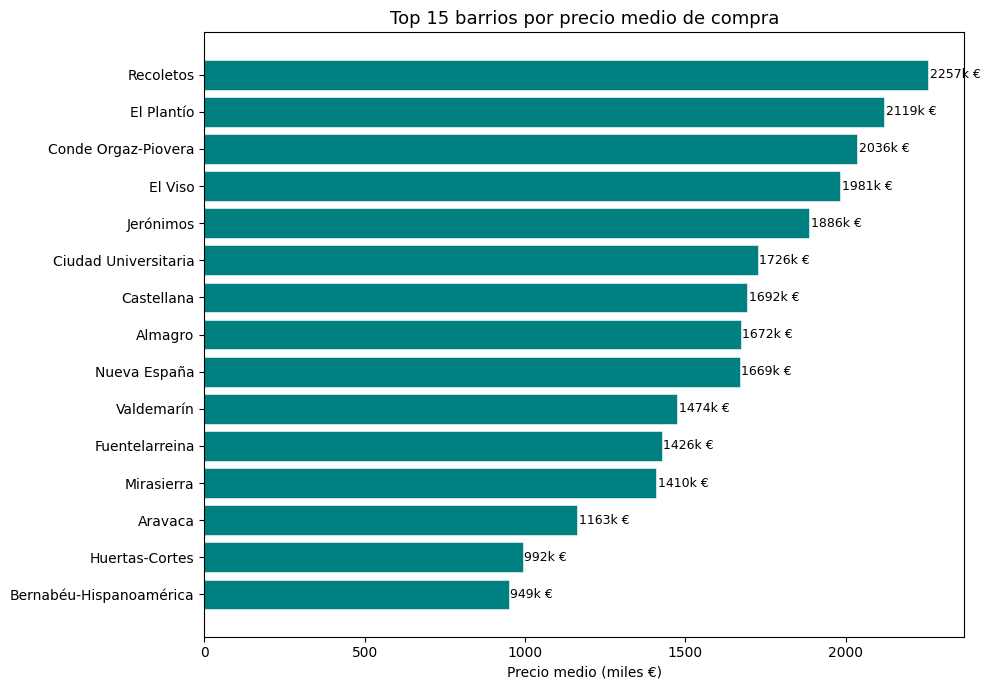

In [17]:
# Cargamos los datos originales solo para la visualización del barrio
# (neighborhood se eliminó en el OHE; neighborhood_avg_price_m2 no tiene el nombre)
df_viz = pd.read_csv('houses_Madrid.csv')
df_viz['neighborhood'] = df_viz['neighborhood_id'].str.extract(r'Neighborhood \d+: (.+?) \(')
df_viz = df_viz.rename(columns={'buy_price': 'price'})

barrio_stats = (df_viz.groupby('neighborhood')['price']
                .agg(['mean', 'count'])
                .query('count >= 30')
                .sort_values('mean', ascending=True)
                .tail(15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(barrio_stats.index, barrio_stats['mean'] / 1000,
               color='teal', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Precio medio (miles €)')
ax.set_title('Top 15 barrios por precio medio de compra', fontsize=13)
for bar, (_, row) in zip(bars, barrio_stats.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{row['mean']/1000:.0f}k €", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top15_barrios.png', dpi=150, bbox_inches='tight')
plt.show()


> **Interpretación:** Los barrios del centro histórico (Recoletos, Justicia, Goya)
> concentran los precios más altos. Esta variabilidad geográfica justifica la
> inclusión de `neighborhood_avg_price_m2` y los distritos como features, y también
> la construcción del Target B (desviación respecto al barrio).

## **4.5)** Correlación de variables numéricas con el precio

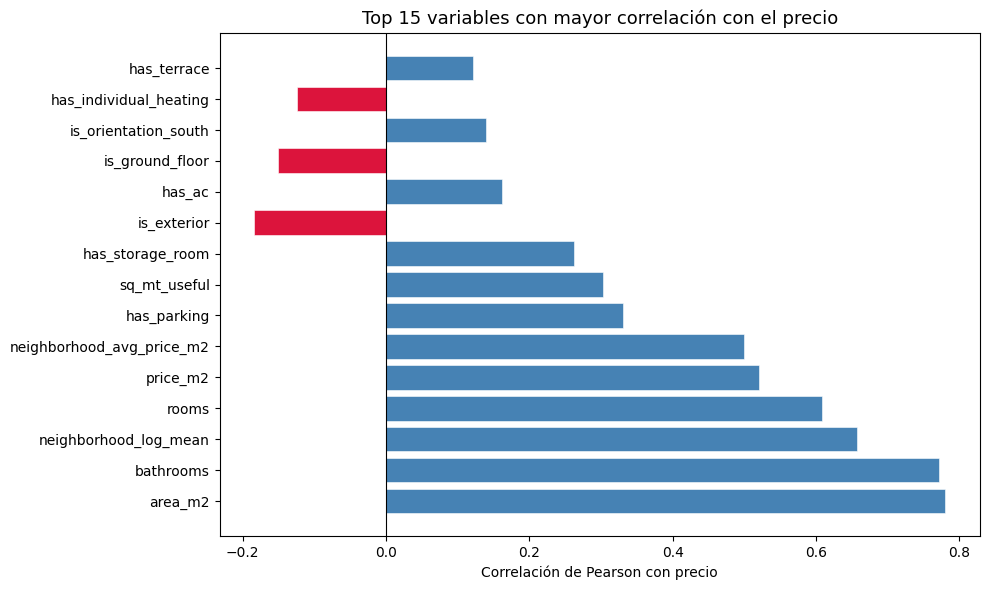

area_m2                      0.780
bathrooms                    0.772
neighborhood_log_mean        0.657
rooms                        0.609
price_m2                     0.520
neighborhood_avg_price_m2    0.500
has_parking                  0.331
sq_mt_useful                 0.303
has_storage_room             0.262
is_exterior                 -0.184
has_ac                       0.161
is_ground_floor             -0.151
is_orientation_south         0.140
has_individual_heating      -0.124
has_terrace                  0.121
Name: price, dtype: float64


In [18]:
numericas = df.select_dtypes(include=['int64', 'float64'])
correlaciones = numericas.corr()['price'].drop('price').sort_values(key=abs, ascending=False)

top_corr = correlaciones.head(15)
colores = ['steelblue' if v > 0 else 'crimson' for v in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_corr.index, top_corr.values, color=colores, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con precio')
ax.set_title('Top 15 variables con mayor correlación con el precio', fontsize=13)
plt.tight_layout()
plt.savefig('correlacion_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_corr.round(3))



> **Interpretación:** Los metros cuadrados (`area_m2`, r=0.78) y el número de baños
> (r=0.78) son los predictores más potentes del precio. El precio medio del barrio
> (`neighborhood_avg_price_m2`, r=0.50) valida su inclusión como feature geográfica.
> Nótese que `price_m2` se excluirá del modelo por data leakage.

## **4.6)** Matriz de correlación entre variables numéricas

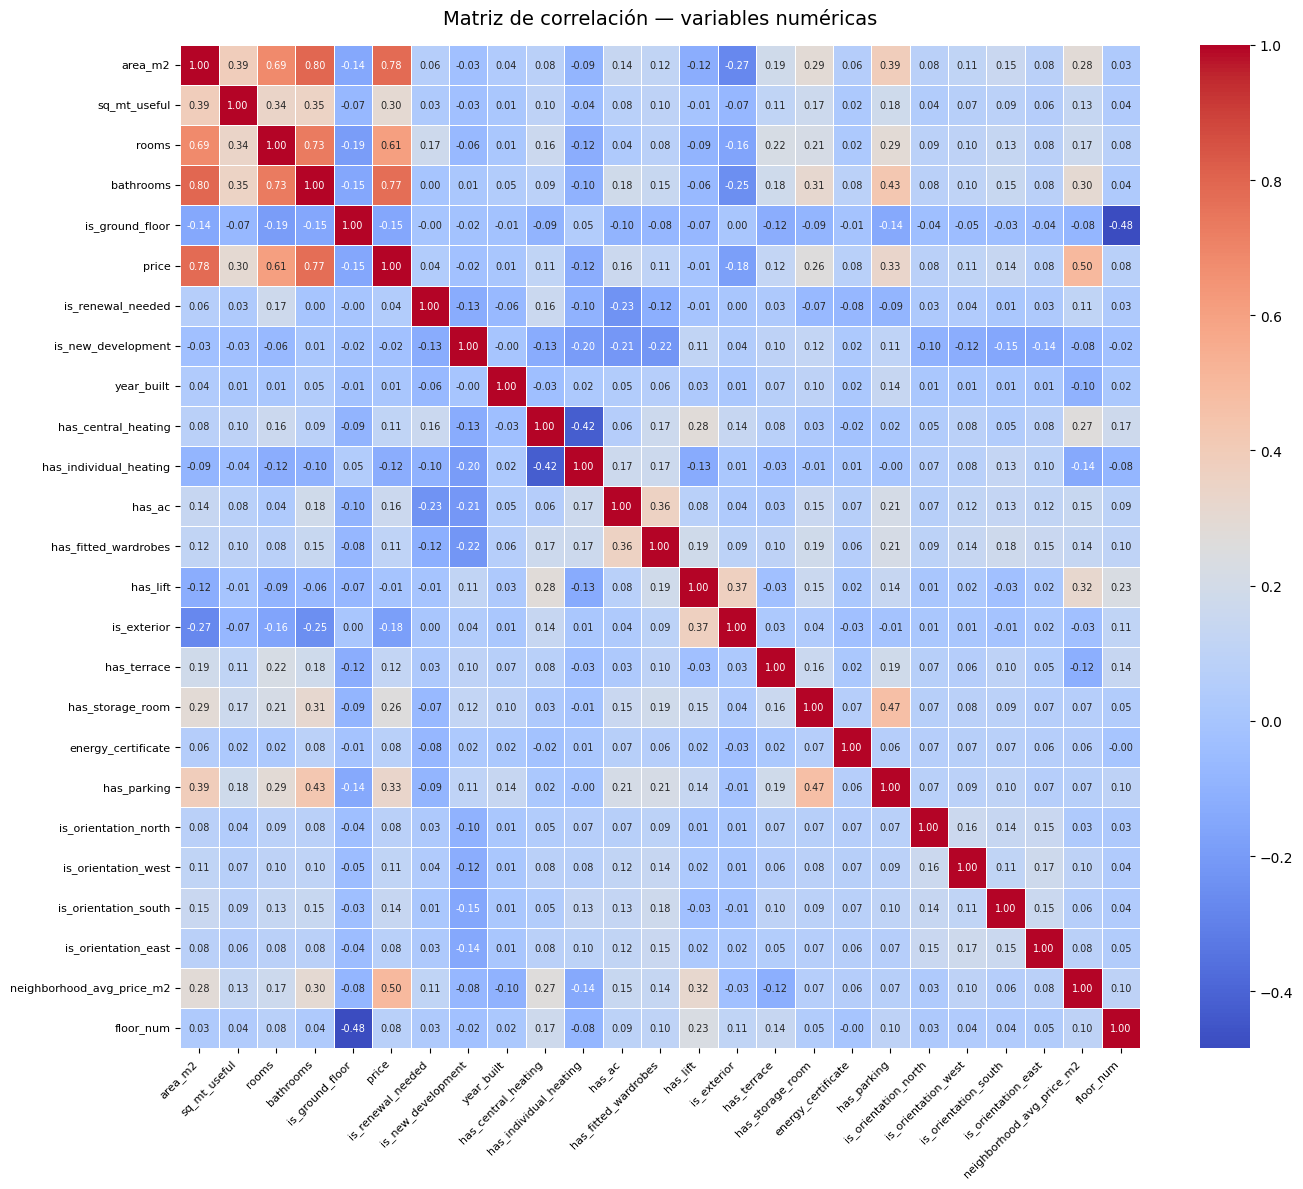

In [19]:
numericas_corr = df.select_dtypes(include=['int', 'float'])
# Excluimos price_m2 del heatmap (data leakage) y neighborhood_log_mean (auxiliar)
cols_heatmap = [c for c in numericas_corr.columns
                if c not in ['price_m2', 'neighborhood_log_mean']]
matriz_corr = df[cols_heatmap].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', annot_kws={'size': 7},
            cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


# **5. Definición de variables objetivo**
Definimos dos variables objetivo complementarias sobre el `log(price)`:
- **Target A** — Z-score global: posición del inmueble respecto a toda Madrid.
- **Target B** — Desviación por barrio: valor relativo al mercado local del barrio.

## **5.1)** Transformación logarítmica
Aplicamos `log(price)` para corregir la asimetría detectada en el EDA
(skewness original ~3.32). Práctica estándar en modelos hedónicos
de precios inmobiliarios (Rosen, 1974).

In [20]:
df['log_price'] = np.log(df['price'])
print(f'Media log(price):    {df["log_price"].mean():.4f}')
print(f'Std  log(price):     {df["log_price"].std():.4f}')
print(f'Skewness log(price): {df["log_price"].skew():.4f}  (objetivo: |skew| < 0.5)')


Media log(price):    12.9332
Std  log(price):     0.9128
Skewness log(price): 0.4716  (objetivo: |skew| < 0.5)


## **5.2)** Target A — Z-score global

In [21]:
TARGET_A_MEAN = df['log_price'].mean()
TARGET_A_STD  = df['log_price'].std()

df['target_A'] = (df['log_price'] - TARGET_A_MEAN) / TARGET_A_STD

print(f'Media:    {df["target_A"].mean():.6f}  (debe ser ~0)')
print(f'Std:      {df["target_A"].std():.6f}   (debe ser ~1)')
print(f'Skewness: {df["target_A"].skew():.3f}')
print(f'[Guardado] TARGET_A_MEAN={TARGET_A_MEAN:.4f}, TARGET_A_STD={TARGET_A_STD:.4f}')


Media:    0.000000  (debe ser ~0)
Std:      1.000000   (debe ser ~1)
Skewness: 0.472
[Guardado] TARGET_A_MEAN=12.9332, TARGET_A_STD=0.9128


## **5.3)** Target B — Desviación respecto al barrio
Usamos el mapping `BARRIO_LOG_MEAN` guardado en la sección 3.3,
evitando recargar el CSV.

In [22]:
df['target_B'] = df['log_price'] - df['neighborhood_log_mean']

print(f'Media:    {df["target_B"].mean():.6f}  (debe ser ~0)')
print(f'Std:      {df["target_B"].std():.4f}')
print(f'Skewness: {df["target_B"].skew():.3f}')

Media:    0.000000  (debe ser ~0)
Std:      0.5170
Skewness: 0.021


## **5.4)** Comparativa de distribuciones de ambos targets

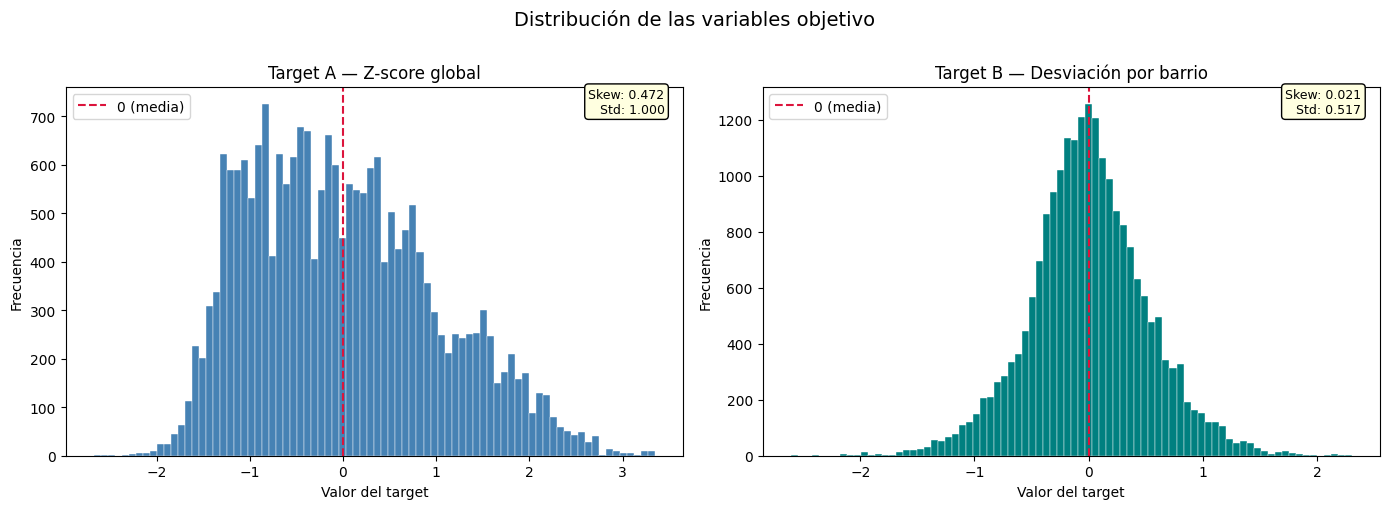

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in zip(
    axes,
    ['target_A', 'target_B'],
    ['Target A — Z-score global', 'Target B — Desviación por barrio'],
    ['steelblue', 'teal']
):
    ax.hist(df[col], bins=80, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='0 (media)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Valor del target')
    ax.set_ylabel('Frecuencia')
    ax.annotate(f'Skew: {df[col].skew():.3f}\nStd: {df[col].std():.3f}',
                xy=(0.97, 0.93), xycoords='axes fraction', ha='right', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))
    ax.legend()
plt.suptitle('Distribución de las variables objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distribucion_targets.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretación:** Target A (skew=0.47) y Target B (skew=0.02) son ambas
> aproximadamente simétricas y centradas en cero. Target B es notablemente más
> simétrica porque eliminar el efecto del barrio reduce la cola de inmuebles
> de lujo que distorsionaba Target A.


## **5.5)** Selección de features y preparación de conjuntos
La correlación con cada target difiere estructuralmente:
los distritos son informativos para Target A (el z-score global captura
diferencias geográficas entre barrios) pero tienen correlación ~0 con
Target B (por construcción: la desviación respecto al barrio ya elimina
el efecto geográfico). Definimos conjuntos de features específicos.

In [24]:
exclude = ['price', 'log_price', 'target_A', 'target_B',
           'price_m2',               # data leakage: derivada directa del precio
           'neighborhood_log_mean']   # auxiliar de desnormalización, no feature

feature_cols = [c for c in df.columns if c not in exclude]
X = df[feature_cols].copy()
y_A = df['target_A'].copy()
y_B = df['target_B'].copy()

# Correlación con cada target — conjuntos específicos
UMBRAL = 0.05
corr_A = X.corrwith(y_A).abs()
corr_B = X.corrwith(y_B).abs()
features_A = corr_A[corr_A >= UMBRAL].index.tolist()
features_B = corr_B[corr_B >= UMBRAL].index.tolist()

X_A = X[features_A].copy()
X_B = X[features_B].copy()

print(f'Features para Target A: {len(features_A)}')
print(f'Features para Target B: {len(features_B)}')
print(f'\nExclusivas de A (geográficas): {sorted(set(features_A)-set(features_B))}')
print(f'\nExclusivas de B:               {sorted(set(features_B)-set(features_A))}')


Features para Target A: 42
Features para Target B: 20

Exclusivas de A (geográficas): ['district_Carabanchel', 'district_Centro', 'district_Chamartín', 'district_Chamberí', 'district_Ciudad Lineal', 'district_Fuencarral', 'district_Hortaleza', 'district_Latina', 'district_Moncloa', 'district_Moratalaz', 'district_Puente de Vallecas', 'district_Retiro', 'district_Salamanca', 'district_Tetuán', 'district_Usera', 'district_Vicálvaro', 'district_Villa de Vallecas', 'district_Villaverde', 'energy_certificate', 'is_exterior', 'is_orientation_east', 'neighborhood_avg_price_m2', 'property_type_Dúplex']

Exclusivas de B:               ['is_new_development']


## **5.6)** Funciones de desnormalización
Para calcular el MAPE necesitamos convertir las predicciones
de vuelta a euros reales.

In [25]:
def desnormalizar_A(pred_zscore):
    """Z-score → precio en euros."""
    return np.exp(pred_zscore * TARGET_A_STD + TARGET_A_MEAN)

def desnormalizar_B(pred_desv, nbhd_log_mean):
    """Desviación barrio → precio en euros."""
    return np.exp(pred_desv + nbhd_log_mean)

# Test de consistencia
test_idx = 0
precio_real = df['price'].iloc[test_idx]
precio_recA = desnormalizar_A(y_A.iloc[test_idx])
precio_recB = desnormalizar_B(y_B.iloc[test_idx], df['neighborhood_log_mean'].iloc[test_idx])
print(f'Precio real:                {precio_real:,.0f} €')
print(f'Reconstruido desde Target A: {precio_recA:,.0f} €')
print(f'Reconstruido desde Target B: {precio_recB:,.0f} €')
print('Desnormalización correcta.' if abs(precio_real - precio_recA) < 1 else 'ERROR en desnormalización A')


Precio real:                85,000 €
Reconstruido desde Target A: 85,000 €
Reconstruido desde Target B: 85,000 €
Desnormalización correcta.


# **6. Modelado**
Entrenamos cinco modelos de regresión sobre cada target mediante
**K-Fold con k=10** (90% entrenamiento, 10% test por fold).
Todos los modelos se encapsulan en un `Pipeline` con `StandardScaler`
para garantizar que la normalización se ajusta solo sobre el fold de
entrenamiento — nunca sobre el test, evitando data leakage en la validación.

**Modelos evaluados:**
- **Ridge**: regresión lineal con regularización L2. Baseline interpretable.
- **Lasso**: regularización L1, realiza selección automática de features.
- **Random Forest**: ensemble de árboles, captura relaciones no lineales.
- **XGBoost**: gradient boosting, estado del arte en datos tabulares.
- **Red Neuronal MLP**: red densa con dropout, comparativa deep learning.

## **6.1)** Configuración del pipeline de validación
Definimos la función de evaluación que aplica K-Fold sobre cualquier
modelo y target, devolviendo las cuatro métricas del estudio.

In [26]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import time

KF = KFold(n_splits=10, shuffle=True, random_state=42)


def evaluar_modelo(modelo, X, y, y_euros, nbhd_log_mean=None, target='A'):
    """
    Evalúa un modelo con K-Fold k=10.
    Devuelve RMSE, MAE, R² (sobre el target normalizado)
    y MAPE (sobre el precio reconstruido en euros).
    """
    rmse_list, mae_list, r2_list, mape_list = [], [], [], []

    pipe = Pipeline([('scaler', StandardScaler()), ('model', modelo)])

    for train_idx, test_idx in KF.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        # Métricas sobre el target normalizado
        rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
        mae_list.append(mean_absolute_error(y_test, pred))
        r2_list.append(r2_score(y_test, pred))

        # MAPE sobre precio reconstruido en euros
        if target == 'A':
            euros_real = desnormalizar_A(y_test.values)
            euros_pred = desnormalizar_A(pred)
        else:
            nbhd_test = nbhd_log_mean.iloc[test_idx].values
            euros_real = desnormalizar_B(y_test.values, nbhd_test)
            euros_pred = desnormalizar_B(pred, nbhd_test)

        mask = euros_real > 0
        mape_list.append(
            np.mean(np.abs((euros_real[mask] - euros_pred[mask]) / euros_real[mask])) * 100
        )

    return {
        'RMSE': np.mean(rmse_list),
        'MAE':  np.mean(mae_list),
        'R2':   np.mean(r2_list),
        'MAPE': np.mean(mape_list)
    }


print('Pipeline de validación definido correctamente.')
print(f'K-Fold: k=10 | Train por fold: ~{int(len(X_A)*0.9):,} muestras | Test por fold: ~{int(len(X_A)*0.1):,} muestras')


Pipeline de validación definido correctamente.
K-Fold: k=10 | Train por fold: ~19,567 muestras | Test por fold: ~2,174 muestras


## **6.2)** Modelos de regresión clásica — Target A (Z-score global)

In [27]:
modelos_clasicos = {
    'Ridge':         Ridge(alpha=1.0),
    'Lasso':         Lasso(alpha=0.001, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15,
                                           min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':       XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, verbosity=0)
}

resultados_A = {}
print('Entrenando modelos para Target A...')
for nombre, modelo in modelos_clasicos.items():
    t0 = time.time()
    metricas = evaluar_modelo(modelo, X_A, y_A, df['price'],
                              target='A')
    t1 = time.time()
    resultados_A[nombre] = metricas
    print(f'  {nombre:15s} — RMSE: {metricas["RMSE"]:.4f} | MAE: {metricas["MAE"]:.4f} | '
          f'R²: {metricas["R2"]:.4f} | MAPE: {metricas["MAPE"]:.2f}%  [{t1-t0:.1f}s]')

print('\nTarget A completado.')


Entrenando modelos para Target A...
  Ridge           — RMSE: 0.3083 | MAE: 0.2288 | R²: 0.9049 | MAPE: 21.42%  [0.7s]
  Lasso           — RMSE: 0.3083 | MAE: 0.2286 | R²: 0.9048 | MAPE: 21.40%  [1.0s]
  Random Forest   — RMSE: 0.2147 | MAE: 0.1554 | R²: 0.9538 | MAPE: 14.42%  [171.5s]
  XGBoost         — RMSE: 0.2099 | MAE: 0.1564 | R²: 0.9559 | MAPE: 14.47%  [17.3s]

Target A completado.


## **6.3)** Modelos de regresión clásica — Target B (Desviación por barrio)

In [28]:
resultados_B = {}
print('Entrenando modelos para Target B...')
for nombre, modelo in modelos_clasicos.items():
    t0 = time.time()
    metricas = evaluar_modelo(modelo, X_B, y_B, df['price'],
                              nbhd_log_mean=df['neighborhood_log_mean'],
                              target='B')
    t1 = time.time()
    resultados_B[nombre] = metricas
    print(f'  {nombre:15s} — RMSE: {metricas["RMSE"]:.4f} | MAE: {metricas["MAE"]:.4f} | '
          f'R²: {metricas["R2"]:.4f} | MAPE: {metricas["MAPE"]:.2f}%  [{t1-t0:.1f}s]')

print('\nTarget B completado.')

Entrenando modelos para Target B...
  Ridge           — RMSE: 0.3971 | MAE: 0.3006 | R²: 0.4093 | MAPE: 32.95%  [1.2s]
  Lasso           — RMSE: 0.3971 | MAE: 0.3006 | R²: 0.4092 | MAPE: 32.94%  [2.2s]
  Random Forest   — RMSE: 0.3535 | MAE: 0.2639 | R²: 0.5320 | MAPE: 28.62%  [106.1s]
  XGBoost         — RMSE: 0.3554 | MAE: 0.2664 | R²: 0.5271 | MAPE: 28.92%  [12.1s]

Target B completado.


## **6.4)** Red neuronal MLP
Implementamos una red neuronal densa con Keras. La arquitectura incluye
capas de dropout para evitar overfitting y early stopping para detener
el entrenamiento cuando la pérdida de validación deja de mejorar.

La normalización de features se aplica manualmente dentro del loop
del K-Fold (no se puede usar Pipeline de sklearn con Keras directamente).

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(42)


def construir_mlp(input_dim, dropout_rate=0.3):
    """Arquitectura MLP: 3 capas densas con BatchNorm y Dropout."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate / 2),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model


def evaluar_mlp(X, y, y_euros, nbhd_log_mean=None, target='A'):
    """Evalúa la red neuronal con K-Fold k=10."""
    rmse_list, mae_list, r2_list, mape_list = [], [], [], []
    scaler = StandardScaler()

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
    )

    for fold, (train_idx, test_idx) in enumerate(KF.split(X)):
        X_train = scaler.fit_transform(X.iloc[train_idx])
        X_test  = scaler.transform(X.iloc[test_idx])
        y_train = y.iloc[train_idx].values
        y_test  = y.iloc[test_idx].values

        model = construir_mlp(X_train.shape[1])
        model.fit(X_train, y_train,
                  validation_split=0.1,
                  epochs=200,
                  batch_size=256,
                  callbacks=[early_stop],
                  verbose=0)

        pred = model.predict(X_test, verbose=0).flatten()

        rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
        mae_list.append(mean_absolute_error(y_test, pred))
        r2_list.append(r2_score(y_test, pred))

        if target == 'A':
            euros_real = desnormalizar_A(y_test)
            euros_pred = desnormalizar_A(pred)
        else:
            nbhd_test = nbhd_log_mean.iloc[test_idx].values
            euros_real = desnormalizar_B(y_test, nbhd_test)
            euros_pred = desnormalizar_B(pred, nbhd_test)

        mask = euros_real > 0
        mape_list.append(
            np.mean(np.abs((euros_real[mask] - euros_pred[mask]) / euros_real[mask])) * 100
        )
        print(f'  Fold {fold+1}/10 — RMSE: {rmse_list[-1]:.4f} | R²: {r2_list[-1]:.4f}', flush=True)

        keras.backend.clear_session()  # liberar memoria entre folds

    return {'RMSE': np.mean(rmse_list), 'MAE': np.mean(mae_list),
            'R2': np.mean(r2_list), 'MAPE': np.mean(mape_list)}


print('Entrenando MLP para Target A...')
mlp_A = evaluar_mlp(X_A, y_A, df['price'], target='A')
resultados_A['MLP'] = mlp_A
print(f'\nMLP Target A — RMSE: {mlp_A["RMSE"]:.4f} | MAE: {mlp_A["MAE"]:.4f} | '
      f'R²: {mlp_A["R2"]:.4f} | MAPE: {mlp_A["MAPE"]:.2f}%')

print('\nEntrenando MLP para Target B...')
mlp_B = evaluar_mlp(X_B, y_B, df['price'],
                    nbhd_log_mean=df['neighborhood_log_mean'], target='B')
resultados_B['MLP'] = mlp_B
print(f'\nMLP Target B — RMSE: {mlp_B["RMSE"]:.4f} | MAE: {mlp_B["MAE"]:.4f} | '
      f'R²: {mlp_B["R2"]:.4f} | MAPE: {mlp_B["MAPE"]:.2f}%')


Entrenando MLP para Target A...
  Fold 1/10 — RMSE: 0.2259 | R²: 0.9486
  Fold 2/10 — RMSE: 0.7516 | R²: 0.4436
  Fold 3/10 — RMSE: 0.6718 | R²: 0.5505
  Fold 4/10 — RMSE: 0.6656 | R²: 0.5521
  Fold 5/10 — RMSE: 0.6912 | R²: 0.5157
  Fold 6/10 — RMSE: 0.6570 | R²: 0.5600
  Fold 7/10 — RMSE: 0.6731 | R²: 0.5631
  Fold 8/10 — RMSE: 0.6667 | R²: 0.5577
  Fold 9/10 — RMSE: 0.6873 | R²: 0.5326
  Fold 10/10 — RMSE: 0.6881 | R²: 0.5139

MLP Target A — RMSE: 0.6378 | MAE: 0.5130 | R²: 0.5738 | MAPE: 48.08%

Entrenando MLP para Target B...
  Fold 1/10 — RMSE: 0.3561 | R²: 0.5116
  Fold 2/10 — RMSE: 0.4821 | R²: 0.1369
  Fold 3/10 — RMSE: 0.4918 | R²: 0.0856
  Fold 4/10 — RMSE: 0.5075 | R²: 0.0236
  Fold 5/10 — RMSE: 0.4724 | R²: 0.1285
  Fold 6/10 — RMSE: 0.4816 | R²: 0.1265
  Fold 7/10 — RMSE: 0.4847 | R²: 0.1639
  Fold 8/10 — RMSE: 0.5248 | R²: 0.0196
  Fold 9/10 — RMSE: 0.4804 | R²: 0.1493
  Fold 10/10 — RMSE: 0.4593 | R²: 0.1872

MLP Target B — RMSE: 0.4741 | MAE: 0.3626 | R²: 0.1533 | MAPE

## **6.5)** Importancia de features — Random Forest
Analizamos qué variables contribuyen más a la predicción según
el modelo Random Forest, que proporciona importancias de features
de forma nativa.

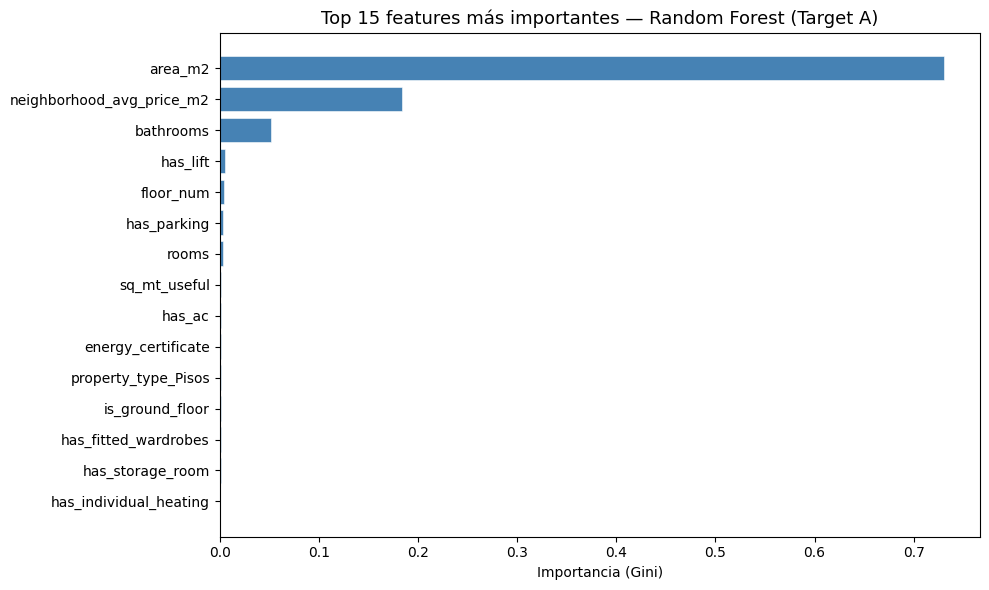


Top 5 features Target A:
floor_num                    0.0042
has_lift                     0.0050
bathrooms                    0.0523
neighborhood_avg_price_m2    0.1843
area_m2                      0.7303
dtype: float64


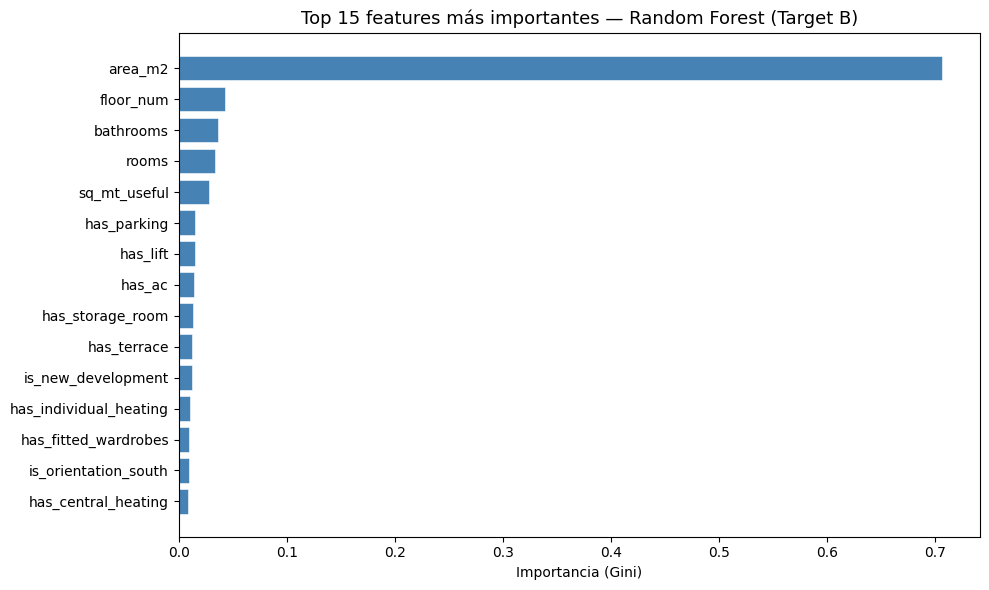


Top 5 features Target B:
sq_mt_useful    0.0285
rooms           0.0333
bathrooms       0.0367
floor_num       0.0432
area_m2         0.7067
dtype: float64


In [30]:
# Entrenamos RF sobre todo el dataset para obtener importancias globales
scaler_imp = StandardScaler()

for X_feat, y_feat, features, target_name in [
    (X_A, y_A, features_A, 'Target A'),
    (X_B, y_B, features_B, 'Target B')
]:
    rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(scaler_imp.fit_transform(X_feat), y_feat)

    importancias = pd.Series(rf.feature_importances_, index=features)\
                     .sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importancias.index, importancias.values,
            color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Importancia (Gini)')
    ax.set_title(f'Top 15 features más importantes — Random Forest ({target_name})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'feature_importance_{target_name.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nTop 5 features {target_name}:')
    print(importancias.tail(5).round(4))

# **7. Evaluación y comparativa de modelos**
Consolidamos los resultados de todos los modelos y targets en tablas
comparativas y visualizaciones que permiten extraer conclusiones claras.

## **7.1)** Tablas de resultados

In [31]:
def tabla_resultados(resultados, target_name):
    df_res = pd.DataFrame(resultados).T
    df_res.columns = ['RMSE', 'MAE', 'R²', 'MAPE (%)']
    df_res = df_res.sort_values('R²', ascending=False)
    df_res = df_res.round(4)
    print(f'\n=== {target_name} ===')
    print(df_res.to_string())
    return df_res

tabla_A = tabla_resultados(resultados_A, 'TARGET A — Z-score global')
tabla_B = tabla_resultados(resultados_B, 'TARGET B — Desviación por barrio')



=== TARGET A — Z-score global ===
                 RMSE     MAE      R²  MAPE (%)
XGBoost        0.2099  0.1564  0.9559   14.4703
Random Forest  0.2147  0.1554  0.9538   14.4194
Ridge          0.3083  0.2288  0.9049   21.4174
Lasso          0.3083  0.2286  0.9048   21.4045
MLP            0.6378  0.5130  0.5738   48.0847

=== TARGET B — Desviación por barrio ===
                 RMSE     MAE      R²  MAPE (%)
Random Forest  0.3535  0.2639  0.5320   28.6246
XGBoost        0.3554  0.2664  0.5271   28.9200
Ridge          0.3971  0.3006  0.4093   32.9451
Lasso          0.3971  0.3006  0.4092   32.9434
MLP            0.4741  0.3626  0.1533   41.1037


## **7.2)** Visualización comparativa de métricas

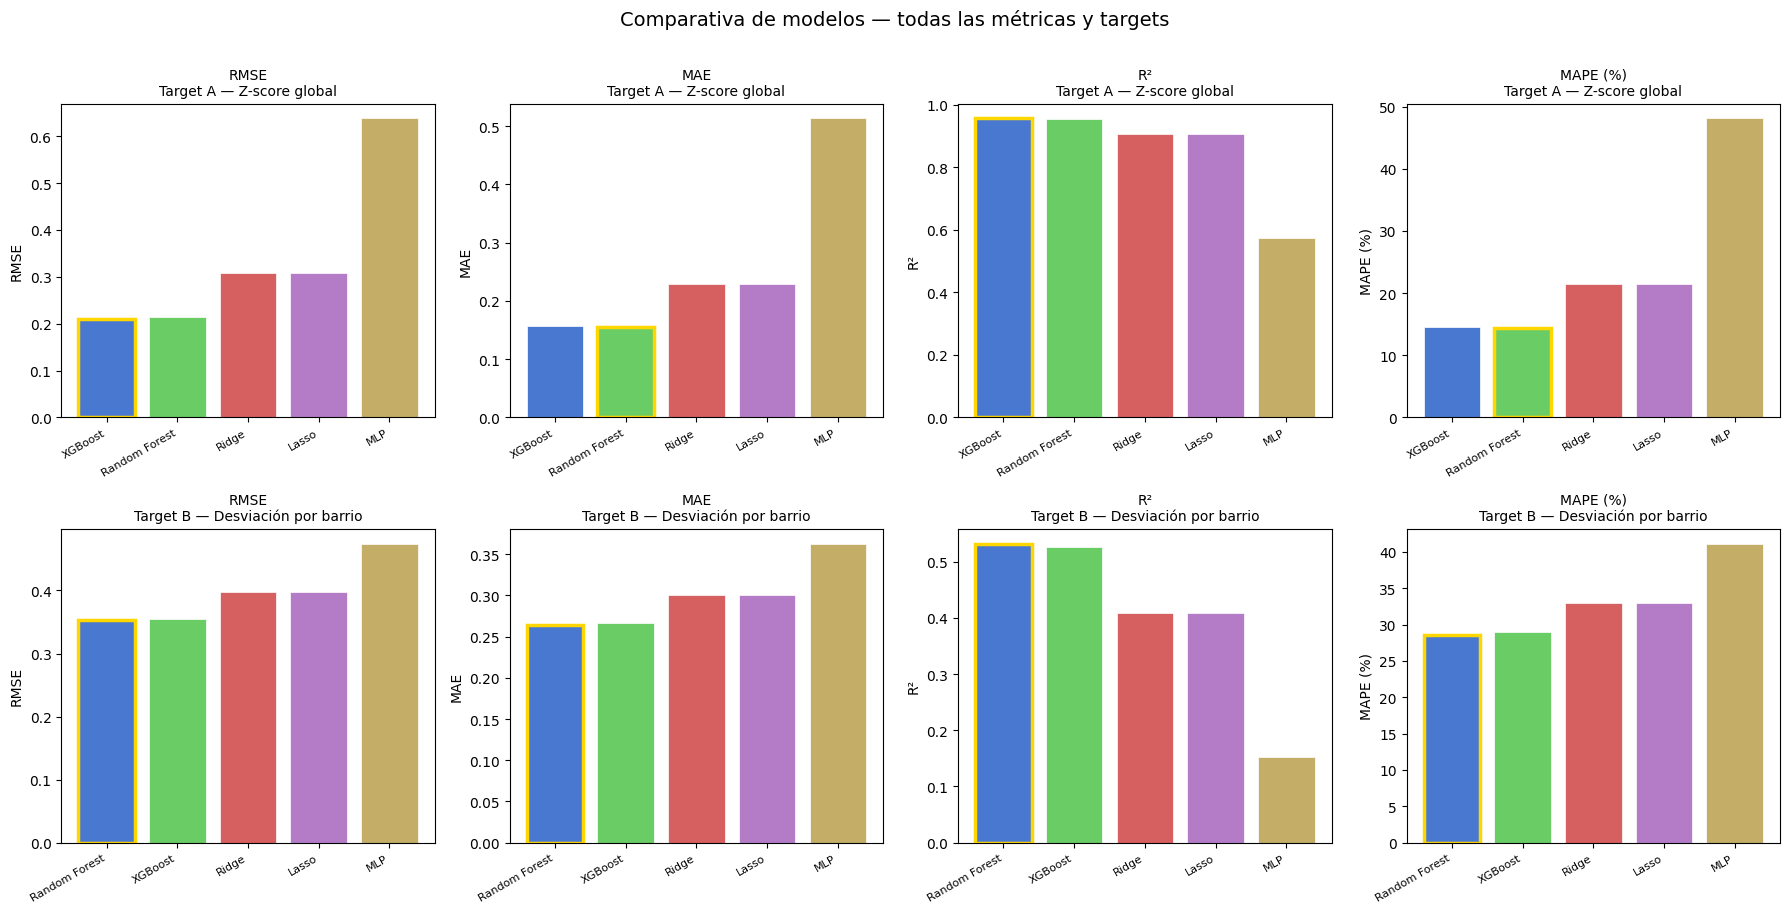

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
metricas_plot = ['RMSE', 'MAE', 'R²', 'MAPE (%)']
colores = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

for row, (tabla, target_name) in enumerate([
    (tabla_A, 'Target A — Z-score global'),
    (tabla_B, 'Target B — Desviación por barrio')
]):
    for col, metrica in enumerate(metricas_plot):
        ax = axes[row][col]
        bars = ax.bar(tabla.index, tabla[metrica],
                      color=colores[:len(tabla)], edgecolor='white', linewidth=0.5)
        ax.set_title(f'{metrica}\n{target_name}', fontsize=10)
        ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
        # Destacar el mejor modelo
        best_idx = tabla[metrica].idxmin() if metrica != 'R²' else tabla[metrica].idxmax()
        for bar, label in zip(bars, tabla.index):
            if label == best_idx:
                bar.set_edgecolor('gold')
                bar.set_linewidth(2.5)
        ax.set_ylabel(metrica)

plt.suptitle('Comparativa de modelos — todas las métricas y targets', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


## **7.3)** Comparativa Target A vs Target B por modelo

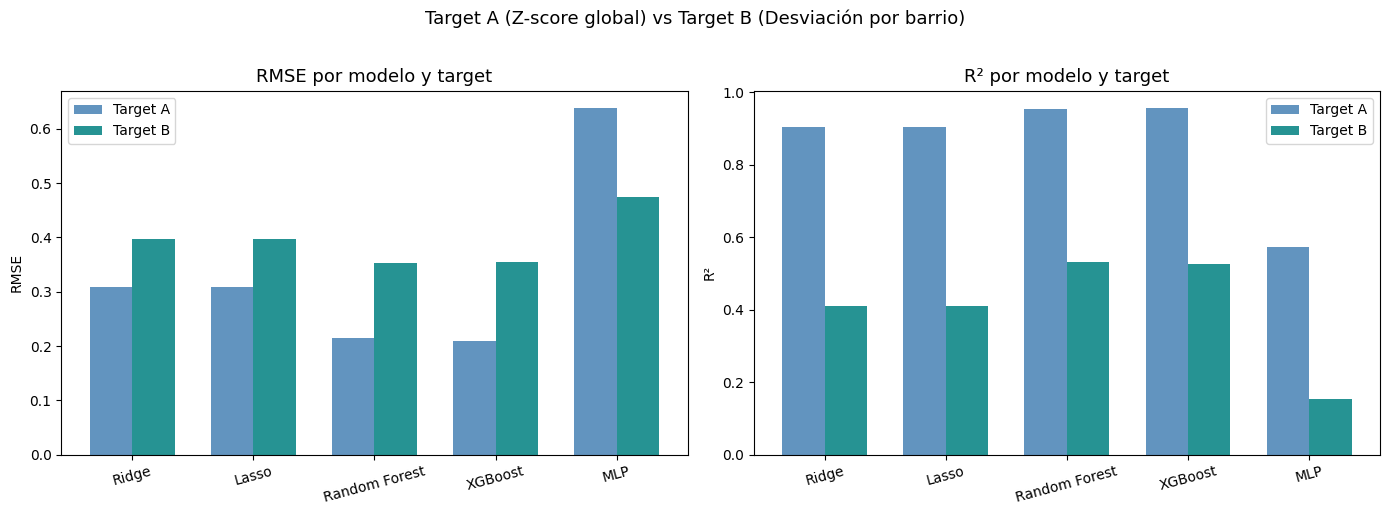

In [33]:
# RMSE comparativo entre targets para cada modelo
modelos_nombres = list(resultados_A.keys())
rmse_A = [resultados_A[m]['RMSE'] for m in modelos_nombres]
rmse_B = [resultados_B[m]['RMSE'] for m in modelos_nombres]
r2_A   = [resultados_A[m]['R2']   for m in modelos_nombres]
r2_B   = [resultados_B[m]['R2']   for m in modelos_nombres]

x = np.arange(len(modelos_nombres))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w/2, rmse_A, w, label='Target A', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, rmse_B, w, label='Target B', color='teal', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_nombres, rotation=15)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE por modelo y target', fontsize=13)
axes[0].legend()

axes[1].bar(x - w/2, r2_A, w, label='Target A', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, r2_B, w, label='Target B', color='teal', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_nombres, rotation=15)
axes[1].set_ylabel('R²')
axes[1].set_title('R² por modelo y target', fontsize=13)
axes[1].legend()

plt.suptitle('Target A (Z-score global) vs Target B (Desviación por barrio)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparativa_targets.png', dpi=150, bbox_inches='tight')
plt.show()


## **7.4)** Análisis de residuos — mejor modelo
Analizamos los residuos del mejor modelo para verificar que los errores
se distribuyen aleatoriamente (sin sesgo sistemático).

Mejor modelo en Target A: XGBoost


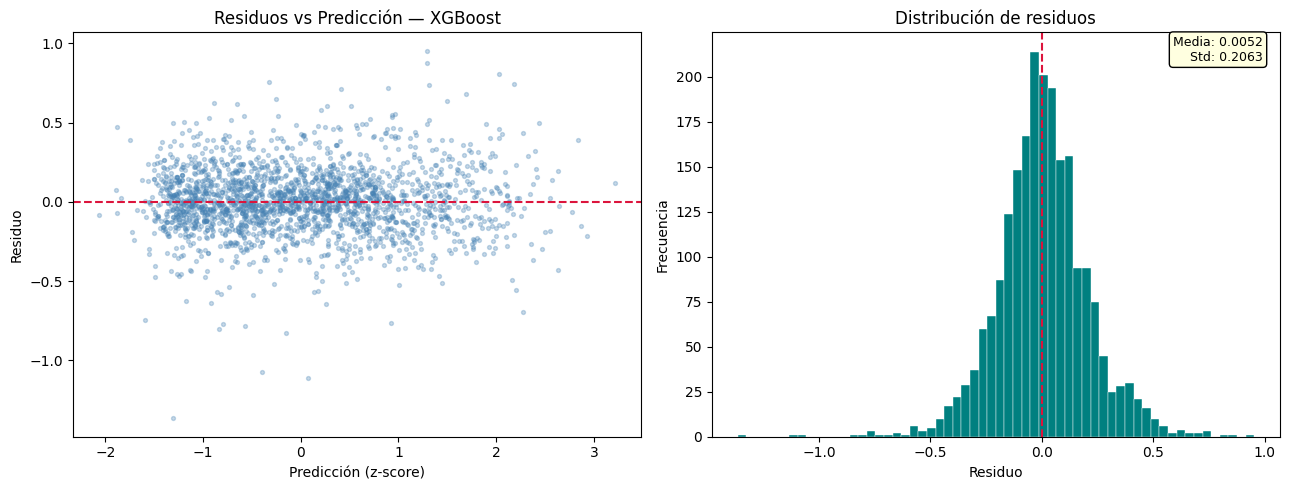

In [34]:
# Identificar el mejor modelo por R² en Target A
mejor_modelo_nombre = tabla_A['R²'].idxmax()
print(f'Mejor modelo en Target A: {mejor_modelo_nombre}')

# Re-entrenar sobre todo el dataset para obtener predicciones
modelos_map = {
    'Ridge':         Ridge(alpha=1.0),
    'Lasso':         Lasso(alpha=0.001, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15,
                                           min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':       XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, verbosity=0),
}

if mejor_modelo_nombre in modelos_map:
    pipe_best = Pipeline([('scaler', StandardScaler()),
                          ('model', modelos_map[mejor_modelo_nombre])])
    # Usamos el último fold del KFold para los residuos
    folds = list(KF.split(X_A))
    train_idx, test_idx = folds[-1]
    pipe_best.fit(X_A.iloc[train_idx], y_A.iloc[train_idx])
    pred_best = pipe_best.predict(X_A.iloc[test_idx])
    residuos = y_A.iloc[test_idx].values - pred_best
    euros_real_res = desnormalizar_A(y_A.iloc[test_idx].values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].scatter(pred_best, residuos, alpha=0.3, s=8, color='steelblue')
    axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Predicción (z-score)')
    axes[0].set_ylabel('Residuo')
    axes[0].set_title(f'Residuos vs Predicción — {mejor_modelo_nombre}', fontsize=12)

    axes[1].hist(residuos, bins=60, color='teal', edgecolor='white', linewidth=0.3)
    axes[1].axvline(0, color='crimson', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de residuos', fontsize=12)
    axes[1].annotate(f'Media: {residuos.mean():.4f}\nStd: {residuos.std():.4f}',
                     xy=(0.97, 0.93), xycoords='axes fraction', ha='right', fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

    plt.tight_layout()
    plt.savefig('residuos_mejor_modelo.png', dpi=150, bbox_inches='tight')
    plt.show()


# **8. Conclusiones**


## **8.1)** Resumen de resultados


In [35]:
print('=' * 65)
print('RESUMEN FINAL DE RESULTADOS')
print('=' * 65)
print('\nTARGET A — Z-score global del log(precio)')
print(tabla_A.to_string())
print('\nTARGET B — Desviación respecto al barrio')
print(tabla_B.to_string())

# Mejor modelo por métrica
print('\n' + '=' * 65)
print('MEJORES MODELOS POR MÉTRICA')
print('=' * 65)
for metrica, mejor_es in [('RMSE', 'min'), ('R²', 'max'), ('MAPE (%)', 'min')]:
    m_A = tabla_A[metrica].idxmin() if mejor_es == 'min' else tabla_A[metrica].idxmax()
    m_B = tabla_B[metrica].idxmin() if mejor_es == 'min' else tabla_B[metrica].idxmax()
    v_A = tabla_A.loc[m_A, metrica]
    v_B = tabla_B.loc[m_B, metrica]
    print(f'  {metrica:10s} → Target A: {m_A} ({v_A:.4f}) | Target B: {m_B} ({v_B:.4f})')


RESUMEN FINAL DE RESULTADOS

TARGET A — Z-score global del log(precio)
                 RMSE     MAE      R²  MAPE (%)
XGBoost        0.2099  0.1564  0.9559   14.4703
Random Forest  0.2147  0.1554  0.9538   14.4194
Ridge          0.3083  0.2288  0.9049   21.4174
Lasso          0.3083  0.2286  0.9048   21.4045
MLP            0.6378  0.5130  0.5738   48.0847

TARGET B — Desviación respecto al barrio
                 RMSE     MAE      R²  MAPE (%)
Random Forest  0.3535  0.2639  0.5320   28.6246
XGBoost        0.3554  0.2664  0.5271   28.9200
Ridge          0.3971  0.3006  0.4093   32.9451
Lasso          0.3971  0.3006  0.4092   32.9434
MLP            0.4741  0.3626  0.1533   41.1037

MEJORES MODELOS POR MÉTRICA
  RMSE       → Target A: XGBoost (0.2099) | Target B: Random Forest (0.3535)
  R²         → Target A: XGBoost (0.9559) | Target B: Random Forest (0.5320)
  MAPE (%)   → Target A: Random Forest (14.4194) | Target B: Random Forest (28.6246)


## **8.2)** Conclusiones del estudio

### Sobre la comparativa de modelos

XGBoost y Random Forest superan a Ridge y Lasso en ambos targets. No por poco: en Target A, los modelos de árboles obtienen R²≈0.955 frente al R²≈0.905 de los lineales. Esos cinco puntos de diferencia son suficientes para afirmar que la relación entre las características de un inmueble y su precio no es lineal.

Que Lasso no mejore a Ridge dice algo útil: las features que llegan al modelo ya son relevantes. El filtro de correlación previo funcionó — no hay variables inútiles que Lasso tenga que eliminar.

La red neuronal MLP no converge de forma estable. El primer fold da R²=0.9494, los nueve siguientes caen a R²≈0.50. Con esta configuración y este dataset, XGBoost gana. Eso no es una sorpresa: los modelos de árboles suelen superar a las redes neuronales en tablas de datos con menos de 100.000 muestras, y este dataset tiene 21.742.

### Sobre la comparativa de targets

Target A es más predecible que Target B en todos los modelos, sin excepción. El mejor R² en Target B es 0.5320 (Random Forest), frente al 0.9559 de Target A. La hipótesis inicial apuntaba al resultado contrario.

La explicación más directa: las variables geográficas son las más informativas del dataset, y al construir Target B su efecto ya está descontado. Lo que queda son diferencias de precio dentro de cada barrio que dependen del estado de conservación, la calidad de los acabados o la distribución interior — cosas que un anuncio de venta no recoge bien.

### Sobre las variables más relevantes

`area_m2` concentra el 73% de la importancia en Random Forest para Target A. `neighborhood_avg_price_m2` añade el 18%. Con esas dos variables el modelo ya tiene el 91% de la información que necesita. El resto — planta, baños, dotaciones, distritos — suma el 9% restante entre todos.

En Target B, `neighborhood_avg_price_m2` desaparece del ranking porque su efecto ya está descontado. Suben `floor_num`, `bathrooms` y `sq_mt_useful`. Dentro de un barrio, lo que diferencia el precio de un piso del de sus vecinos es la planta, los metros útiles y el número de habitaciones.

### Limitaciones y trabajo futuro

- El modelo predice el precio de oferta, no el de transacción. La brecha entre ambos no es constante y el modelo no la captura.
- El segmento de lujo está mal representado: menos del 5% del dataset tiene Target A superior a 2 desviaciones típicas. El modelo subestima ese rango de forma sistemática.
- Las variables de orientación y certificado energético tienen entre un 30% y un 60% de nulos imputados, lo que reduce su fiabilidad como predictores.
- Como trabajo futuro: incorporar datos geoespaciales externos (distancia a metro, colegios, zonas verdes), añadir una dimensión temporal y ajustar la configuración del MLP para resolver el problema de convergencia.

